In [152]:
# What we're going to cover
# (broadly)

# . Input shapes and output shapes of a classification model (features and labels)
# . Creating custom data to view, fit on and predict on
# . Steps in modelling
# . Creating a model, setting a loss function and optimiser, creating a training loop, evaluating a
# model

# . Saving and loading models
# . Harnessing the power of non-linearity
# . Different classification evaluation methods

# . Architecture of a neural network classification model

In [153]:
# Now we've setup device agnostic code, let's create a model that:
# 1. Subclasses nn.Module (almost all models in PyTorch subclass nn.Module)
# 2. Create 2 nn.Linear() layers that are capable of handling the shapes of our data
# 3. Defines a forward() method that outlines the forward pass (or forward computation) of the model
# 4. Instatiate an instance of our model class and send it to the target device

In [154]:
# check "playground.tensorflow.org" website to visualize neural neutron as well...
# also go to figjam.new for drawing visual...
# using nn.Linear(in_features, out_features)
# 1 # Let's replicate the model above using nn.Sequential()
# 2 model_0 = nn.Sequential(
# nn.Linear(in_features=2, out_features=5),
# # nn.Linear(in_features=5, out_features=1)
# 5 ).to

import torch

torch.manual_seed(56)
array = torch.randn(size=(200,1))

array.squeeze()

# note: 2d input -> 2d output 
# ndim of input same as ndim of output


tensor([-0.1818, -1.2626,  0.1653,  0.3704, -1.0668, -0.2279, -0.6632, -0.7974,
        -2.4672, -0.2256,  0.9193, -2.3837,  0.3504,  1.5977,  0.4538, -0.8043,
        -1.2410, -0.5429, -0.5360,  0.1308,  0.1566, -0.4839, -0.1696, -0.6816,
        -0.4890,  1.0724, -0.5721, -0.8780, -1.1501,  0.6873, -0.3229,  0.1101,
        -1.2336, -0.2876, -2.0738, -0.6220,  1.3446,  0.1519,  1.1278,  0.9867,
        -0.0587,  0.0853,  0.8843, -1.3925,  1.4688, -0.8016,  0.3758,  1.2531,
        -2.2203, -1.4825, -0.3081,  0.4919,  1.2713,  1.7328,  1.7120,  0.3647,
         0.1547, -0.9772, -0.4345, -0.5821, -1.7497,  0.2868, -0.0539,  0.5281,
        -0.3045, -1.1295,  0.9231, -0.2582, -0.2193, -0.1915, -0.4593, -0.6167,
        -0.9104, -0.6931, -0.8417,  1.1105,  1.0168,  0.7563, -0.6482, -0.5825,
        -2.3152,  0.0918, -0.2601,  0.6355, -0.6545,  1.4767,  0.8889, -0.5120,
        -0.7590,  1.6613,  0.2806,  0.7200, -0.3295,  1.5448,  0.0256, -1.6934,
        -1.1652, -0.7626, -0.0939, -0.04

In [155]:
# 2.1 Setup loss function and optimizer
# Which loss function or optimizer should you use?
# Again ... this is problem specific.
# For example for regression you might want MAE or MSE (mean absolute error or mean squared error).
# For classification you might want binary cross entropy or categorical cross entropy (cross entropy).
# As a reminder, the loss function measures how wrong your models predictions are.
# And for optimizers, two of the most common and useful are SGD and Adam, however PyTorch has many built-in options.
# . For some common choices of loss functions and optimizers -https://www.learnpytorch.io/02_pytorch_classification/#21-setup-loss-
# function-and-optimizer
# . For the loss function we're going to use torch.nn.BECWithLogitsLoss(), for more on what binary cross entropy (BCE) is, check out this
# article - https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a
# . For a defintion on what a logit is in deep learning - https://stackoverflow.com/a/52111173/7900723
# . For different optimizers see torch.optim

In [156]:
# Output activation
# should be:
# Sigmoid (torch.sigmoid in PyTorch) => small classification

# Softmax ( torch.softmax => multiclassification (more than 2)
# in PyTorch)

#  # Setup the loss function
#  # loss_fn = nn. BCELoss() # BCELoss = requires inputs to have gone through the sigmoid a
#  nn. Sequential(
# nn.Sigmoid(),
# nn.BCELoss()
# ) turns to this algorithm below:
# loss_fn = nn.BCEWithLogitsLoss() BCEWithLogitsLoss = sigmoid activation function built



In [157]:
# - 3. Train model

# To train our model, we're going to need to build a training loop with the following steps:
# 1. Forward pass
# 2. Calculate the loss
# 3. Optimizer zero grad
# 4. Loss backward (backpropagation)
# 5. Optimizer step (gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

# Our model outputs are going to be raw ** logits **.

# We can convert these ** logits ** into **prediction** probabilities by passing them to
# some kind of activation function (e.g. sigmoid for binary classification and
# softmax for multiclass classification).
# Then we can convert our model's prediction probabilities to prediction labels by either rounding them or taking the argmax().

In [158]:
# Start coding...

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [159]:
x, y = make_circles(n_samples=1000, noise=0.03, random_state=300)
# convert to tensor
x = torch.tensor(x, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=300)

# import pandas
# # circles = pandas.DataFrame({
# #     "X1": x[:, 0],
# #     "X2": x[:, 1],
# #     "labels" : y
# # })

# # circles



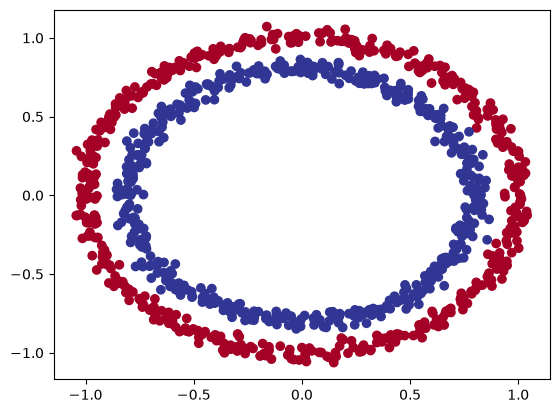

In [160]:
# Visualize the data of x and y...|

plt.scatter(x=x[:, 0], y=x[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [161]:
# creating circles model

class Circles(nn.Module):

    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=5)
        self.layer2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer2(self.layer1(x))


# accuracy...
def accuracy(y_true, y_preds):
     correct = torch.eq(y_true, y_preds).sum().item()
     acc = correct/len(y_preds) * 100
     return acc

In [162]:
# writing model code with loss function and optimizer

model = Circles()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [163]:
# training loops

epochs = 500

for epoch in range(epochs):
    model.train()
    logits = model(x_train).squeeze()
    y_preds = torch.round(torch.sigmoid(logits))
    loss = loss_fn(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    acc_train = accuracy(y_train, y_preds)

    model.eval()
    with torch.inference_mode():
        test_logits = model(x_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        acc_test = accuracy(y_test, test_preds)

    if epoch % 10 == 0:
        print(f"epoch: {epoch}")
        print(f"loss_train:{loss}")
        print(f"test_train:{test_loss}")
        print(f"acc_train:{acc_train:.2f}")
        print(f"acc_test:{acc_test: .2f}")


epoch: 0
loss_train:0.7169433832168579
test_train:0.7001774311065674
acc_train:49.25
acc_test: 53.00
epoch: 10
loss_train:0.7051867842674255
test_train:0.6934403777122498
acc_train:46.88
acc_test: 49.00
epoch: 20
loss_train:0.7002628445625305
test_train:0.6915414929389954
acc_train:45.25
acc_test: 50.00
epoch: 30
loss_train:0.6980523467063904
test_train:0.691264271736145
acc_train:47.25
acc_test: 51.50
epoch: 40
loss_train:0.696928083896637
test_train:0.6914471387863159
acc_train:48.38
acc_test: 50.50
epoch: 50
loss_train:0.6962555646896362
test_train:0.6917073726654053
acc_train:48.25
acc_test: 52.50
epoch: 60
loss_train:0.6957866549491882
test_train:0.691939115524292
acc_train:49.00
acc_test: 52.50
epoch: 70
loss_train:0.695422887802124
test_train:0.6921268701553345
acc_train:49.00
acc_test: 52.00
epoch: 80
loss_train:0.695122480392456
test_train:0.6922791004180908
acc_train:49.62
acc_test: 53.00
epoch: 90
loss_train:0.694865882396698
test_train:0.6924076676368713
acc_train:49.50
acc

In [164]:
# ## 4. Make predictions and evaluate the model

# From the metrics it looks like our model isn't learning anything ...

# So to inspect it let's make some predictions and make them visual!

# In other words, "Visualize, visualize, visualize!"

# To do so, we're going to import a function called plot_decision_boundary()'

# go to the website "MadewithHtml" to learn more about neural network MLops

In [165]:
# improving a model (from a model perspective)

#  * Add more layers - give the model more chances to learn about patterns in the data
# # * Add more hidden units - go from 5 hidden units to 10 hidden units
# * Fit for longer -> more epochs
# * Changing the activation functions
# Change the learning rate
# Change the loss function

# These options are all from a model's perspective because they deal directly with
# the model, rather than the data.

# And because these options are all values we (as machine learning engineers and data scientists) can change, they are referred as
# hyperparameters.


# Common ways to improve a deep model:
# . Adding layers
# . Increase the number of hidden units
# . Change/add activation functions
# . Change the optimization function
# (because you can alter each of
# these, they're hyperparameters)

# . Change the learning rate
# . Fitting for longer



# The exploding gradient problem describes a situation in the training of neural
# networks where the gradients used to update the weights grow
# exponentially. This prevents the backpropagation algorithm from making
# reasonable updates to the weights, and learning becomes unstable. 31 Oct 2021

In [166]:
# import requests
# from pathlib import Path

# response = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
# if Path("helper_function.py").is_file():
#     print("file already exists")
# else:
#     with open("helper_function.py", "wb") as f:
#         f.write(response.content)

In [167]:
# import numpy as np

# map = np.meshgrid([3,5], [7, -3])

# xx, yy = map

# print(xx.ravel())
# print(yy.ravel())

# column = np.column_stack((xx.ravel(), yy.ravel()))
# column

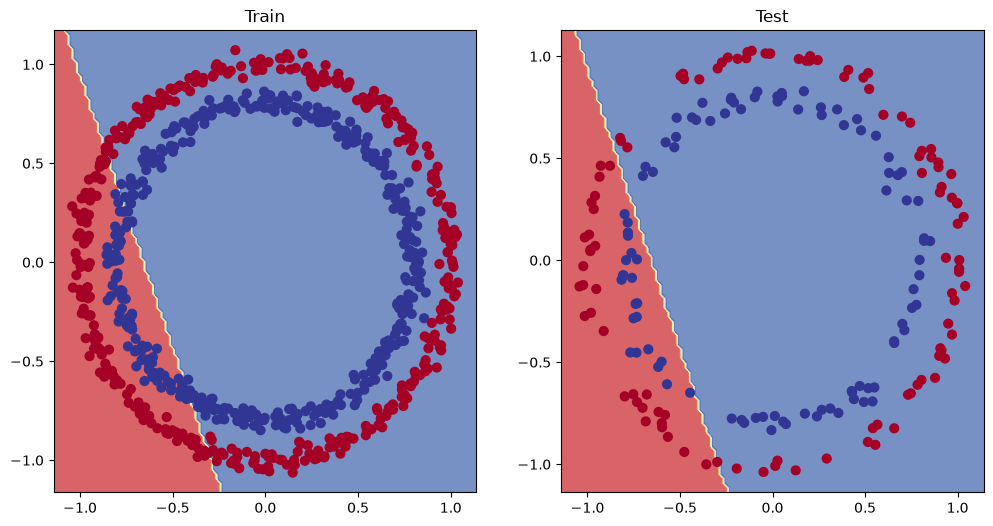

In [168]:
from helper_function import plot_decision_boundary

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model, x_test, y_test)

In [ ]:
class Cicles_V2(nn.Module):

      def __init__(self):
            super().__init__()
            self.layer1 = nn.Linear(in_features=2, out_features=10)
            self.layer2 = nn.Linear(in_features=10, out_features=10)
            self.layer3 = nn.Linear(in_features=10, out_features=1)

      def forward(self, x:torch.Tensor) -> torch.Tensor:
            return self.layer3(self.layer2(self.layer1(x)))

model_v2 = Cicles_V2()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(params=model_v2.parameters(), lr=0.1)

epochs = 1000

for epoch in range(epochs):
      model_v2.train()
      y_logits = model_v2(x_train).squeeze()
      y_preds = torch.round(torch.sigmoid(y_logits))
      loss = loss_fn(y_logits, y_train)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      acc_train = accuracy(y_train, y_preds)

      model_v2.eval()
      with torch.inference_mode():
            test_logits = model_v2(x_test).squeeze()
            test_preds = torch.round(torch.sigmoid(test_logits))
            test_loss = loss_fn(test_logits, y_test)

            acc_test = accuracy(y_test, test_preds)

      if epoch % 10 == 0:
            print(f"Epoch:{epoch} | loss_train:{loss} | acc_train:{acc_train: .2f} | loss_test:{test_loss} | acc_test:{acc_test: .2f} ")



ValueError: Target size (torch.Size([200])) must be the same as input size (torch.Size([200, 1]))

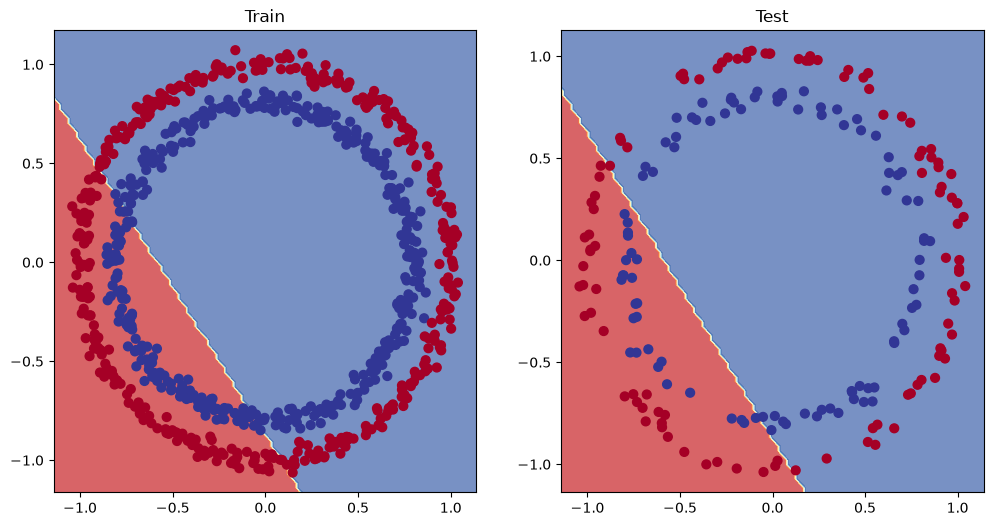

In [170]:
# ploting decision boundary
from helper_function import plot_decision_boundary

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_v2, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_v2, x_test, y_test)

In [ ]:
# Since our model doesnt learn anything, let's try using smaller problem to confirm if this model can learn linearly...

class LinearRegression_V2(nn.Module):

      def __init__(self):
            super().__init__()
            self.layer1 = nn.Linear(in_features=1, out_features=10)
            self.layer2 = nn.Linear(in_features=10, out_features=5)
            self.layer3 = nn.Linear(in_features=5, out_features=1)

      def forward(self, x:torch.Tensor) -> torch.Tensor:
            return self.layer3(self.layer2(self.layer1(x)))

# def accuracy(y_true, y_preds):
#      correct = torch.eq(y_true.squeeze(), y_preds.squeeze()).sum().item()
#      acc = correct/len(y_preds.squeeze()) * 100
#      return acc



w = 0.7
b = 0.3
start = 0
end = 9
step = 0.01

x_reg = torch.arange(start, end, step).unsqueeze(dim=1)
y_reg = x_reg * w + b

train_split = int(0.8 * len(x_reg))
x_train, x_test = x_reg[: train_split], x_reg[train_split :]
y_train, y_test = y_reg[: train_split], y_reg[train_split :]

torch.manual_seed(2026)

model_v3 = LinearRegression_V2()



epochs = 990

loss_fn = nn.L1Loss()
optimizer = optim.SGD(params=model_v3.parameters(), lr=0.001)

for epoch in range(epochs):
    model_v3.train()
    y_preds = model_v3(x_train)
    loss = loss_fn(y_preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    acc_train = accuracy(y_train, y_preds)

    model_v3.eval()
    with torch.inference_mode():
        test_preds = model_v3(x_test)
        test_loss = loss_fn(test_preds, y_test)

        acc_test = accuracy(y_test, test_preds)

    if epoch % 10 == 0:
        print(f"Epoch:{epoch} | loss:{loss} | acc_train: {acc_train:.2f} | test_loss:{test_loss:.2f} | acc_test: {acc_test}")



Epoch:0 | loss:3.7677602767944336 | acc_train: 0.00 | test_loss:8.18 | acc_test: 0.0
Epoch:10 | loss:3.475316286087036 | acc_train: 0.00 | test_loss:7.54 | acc_test: 0.0
Epoch:20 | loss:3.205291509628296 | acc_train: 0.00 | test_loss:6.95 | acc_test: 0.0
Epoch:30 | loss:2.9501750469207764 | acc_train: 0.00 | test_loss:6.38 | acc_test: 0.0
Epoch:40 | loss:2.7030346393585205 | acc_train: 0.00 | test_loss:5.84 | acc_test: 0.0
Epoch:50 | loss:2.4572527408599854 | acc_train: 0.00 | test_loss:5.29 | acc_test: 0.0
Epoch:60 | loss:2.2062835693359375 | acc_train: 0.00 | test_loss:4.73 | acc_test: 0.0
Epoch:70 | loss:1.9434173107147217 | acc_train: 0.00 | test_loss:4.15 | acc_test: 0.0
Epoch:80 | loss:1.6615324020385742 | acc_train: 0.00 | test_loss:3.52 | acc_test: 0.0
Epoch:90 | loss:1.3528276681900024 | acc_train: 0.00 | test_loss:2.83 | acc_test: 0.0
Epoch:100 | loss:1.0085067749023438 | acc_train: 0.00 | test_loss:2.05 | acc_test: 0.0
Epoch:110 | loss:0.6184045672416687 | acc_train: 0.00 | 

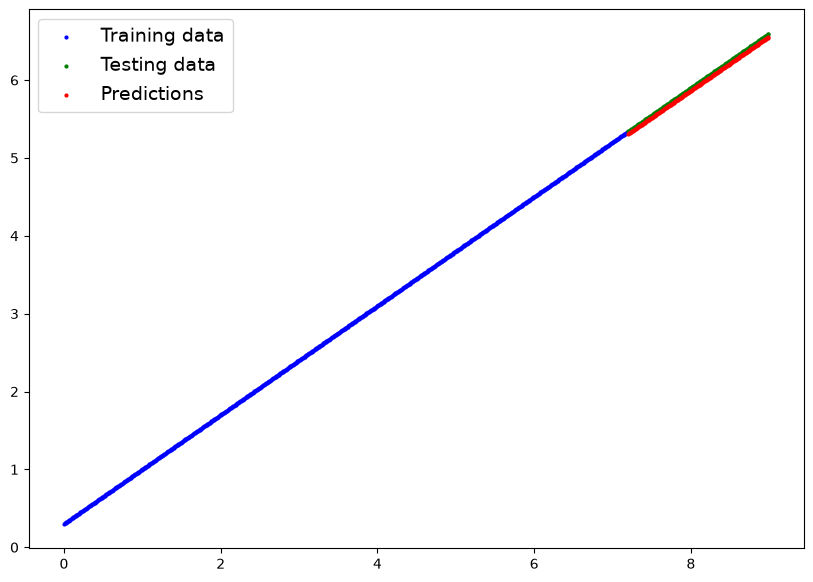

In [173]:
from helper_function import plot_predictions
model.eval()
with torch.inference_mode():
   y_preds = model_v3(x_test)

plot_predictions(train_data=x_train, train_labels=y_train, test_data=x_test, test_labels=y_test, predictions=y_preds)

# model.state_dict()

In [ ]:
### 6.2 Building a model with non-linearity

# Artificial neural networks are a large combination of linear (straight) and
# non-straight (non-linear) functions which are potentially able to find patterns in
# data.

In [207]:
# rewriting non-linears layers to sort this problem to resolved this model not learning anything...

import torch
from torch import nn
import torch.optim as optim
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split


# data
n_samples = 1000

x, y = make_circles(n_samples, noise=0.03, random_state=2026)
x, y = torch.from_numpy(x).type(torch.float), torch.from_numpy(y).type(torch.float)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)

# writing the model

class Circles_V3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(in_features=2, out_features=10)
        self.layer2 = nn.Linear(in_features=10, out_features=10)
        self.layer3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        z = self.relu(self.layer1(x))
        z = self.relu(self.layer2(z))
        z = self.layer3(z)
        return z
    
# defining model and writing manual seed

torch.manual_seed(2026)

model_v3 = Circles_V3()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(params=model_v3.parameters(), lr=0.1)

# training loop

epoch = 1000

for epoch in range(epochs):
    model_v3.train()
    y_logits = model_v3(x_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    acc_train = accuracy(y_train, y_preds)
    loss = loss_fn(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model_v3(x_test).squeeze()
        test_preds = torch.round(torch.sigmoid(test_logits))
        acc_test = accuracy(y_test, test_preds)
        loss_test = loss_fn(test_logits, y_test)


    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | loss_train:{loss} | acc_train: {acc_train} | loss_test: {loss_test} | acc_test: {acc_test}")   


    

Epoch: 0 | loss_train:0.6972037553787231 | acc_train: 50.625 | loss_test: 0.7028853893280029 | acc_test: 47.5
Epoch: 10 | loss_train:0.6949217319488525 | acc_train: 50.625 | loss_test: 0.6991885900497437 | acc_test: 47.5
Epoch: 20 | loss_train:0.6937969923019409 | acc_train: 50.625 | loss_test: 0.6970707178115845 | acc_test: 47.5
Epoch: 30 | loss_train:0.693208634853363 | acc_train: 50.625 | loss_test: 0.6957917809486389 | acc_test: 47.5
Epoch: 40 | loss_train:0.6928674578666687 | acc_train: 50.625 | loss_test: 0.6949840784072876 | acc_test: 47.5
Epoch: 50 | loss_train:0.6926420331001282 | acc_train: 50.625 | loss_test: 0.6944449543952942 | acc_test: 47.5
Epoch: 60 | loss_train:0.6924691796302795 | acc_train: 53.625 | loss_test: 0.6940653920173645 | acc_test: 52.5
Epoch: 70 | loss_train:0.692318856716156 | acc_train: 54.87499999999999 | loss_test: 0.6937820315361023 | acc_test: 47.5
Epoch: 80 | loss_train:0.6921757459640503 | acc_train: 53.37499999999999 | loss_test: 0.6935621500015259

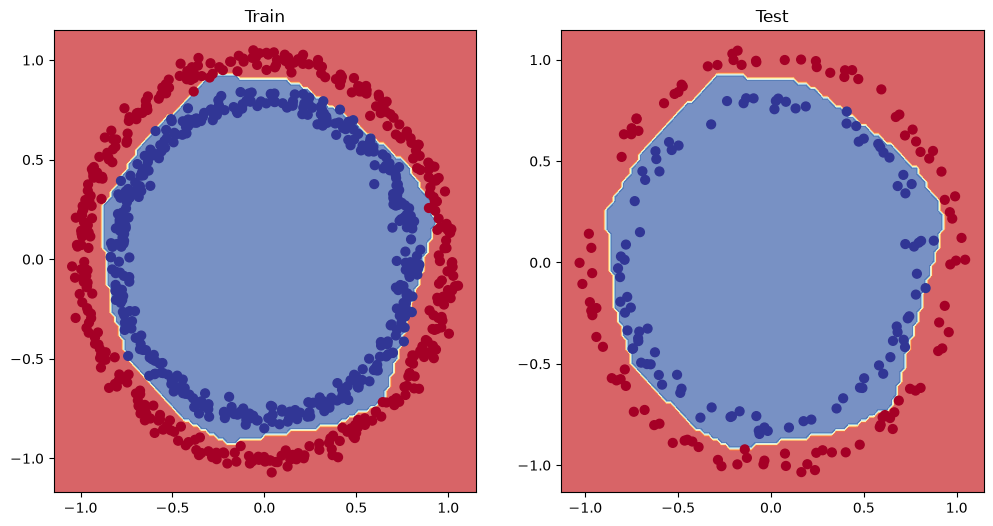

In [208]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_v3, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_v3, x_test, y_test)

In [ ]:
1 # spam or not spam
2 # credit cards = fraud or not fraud
3 # insurance claims = It fault or not fault